# Sales Revenue Analysis

Analyzes the `SalesData` sheet from `practice_dataset.xlsx`: computes revenue, ranks products, and visualizes daily revenue trends.

**Data source**: `data/practice_dataset.xlsx` (sheet: `SalesData`)

**Expected columns**: `Date`, `Product`, `Quantity`, `Price`

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

## Load Data

In [3]:
DATA_PATH = 'data/practice_dataset.xlsx'

sales_df = pd.read_excel(DATA_PATH, sheet_name='SalesData')
sales_df.head()

,Date,Product,Quantity,Price
0,2023-02-21,Phone,3,752
1,2023-01-15,Tablet,4,853
2,2023-03-13,Laptop,2,1343
3,2023-03-02,Monitor,2,1761
4,2023-01-21,Laptop,5,1181


## Compute Revenue

In [4]:
sales_df['Revenue'] = sales_df['Quantity'] * sales_df['Price']
sales_df.head()

,Date,Product,Quantity,Price,Revenue
0,2023-02-21,Phone,3,752,2256
1,2023-01-15,Tablet,4,853,3412
2,2023-03-13,Laptop,2,1343,2686
3,2023-03-02,Monitor,2,1761,3522
4,2023-01-21,Laptop,5,1181,5905


## Revenue per Product

Total revenue and each product's share of overall revenue.

In [5]:
revenue_per_product = (
    sales_df.groupby('Product')['Revenue']
    .sum()
    .reset_index()
    .sort_values(by='Revenue', ascending=False)
    .reset_index(drop=True)
)

revenue_per_product['RevenueShare(%)'] = (
    revenue_per_product['Revenue'] / revenue_per_product['Revenue'].sum() * 100
).round(2)

revenue_per_product

,Product,Revenue,RevenueShare(%)
0,Tablet,151943,23.94
1,Laptop,141201,22.25
2,Headphones,131501,20.72
3,Phone,117580,18.53
4,Monitor,92463,14.57


## Top 3 Products by Revenue

In [6]:
top_3_products = revenue_per_product.head(3)
top_3_products

,Product,Revenue,RevenueShare(%)
0,Tablet,151943,23.94
1,Laptop,141201,22.25
2,Headphones,131501,20.72


## Daily Revenue Trend

In [7]:
daily_revenue = sales_df.groupby('Date')['Revenue'].sum().reset_index()
daily_revenue.head()

,Date,Revenue
0,2023-01-01,3797
1,2023-01-02,9014
2,2023-01-03,11157
3,2023-01-04,16640
4,2023-01-05,4634


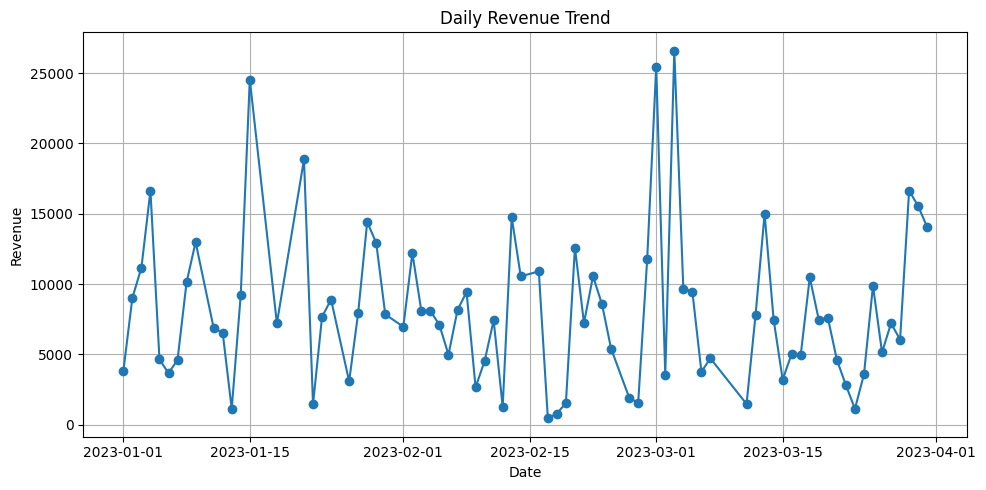

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(daily_revenue['Date'], daily_revenue['Revenue'], marker='o')
plt.title('Daily Revenue Trend')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.grid(True)
plt.tight_layout()
plt.show()

## Revenue Share by Product (Bar Chart)

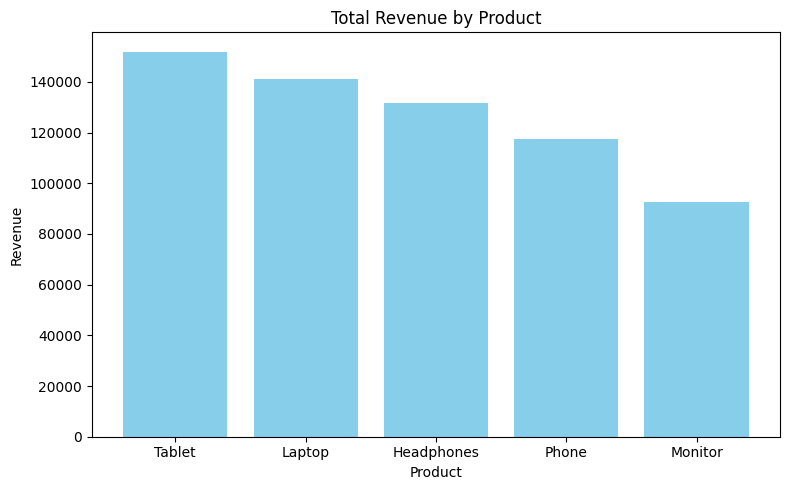

In [9]:
plt.figure(figsize=(8, 5))
plt.bar(revenue_per_product['Product'], revenue_per_product['Revenue'], color='skyblue')
plt.title('Total Revenue by Product')
plt.xlabel('Product')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()